In [2]:


import numpy as np

import pylab as pl
#pl.rcParams['figure.figsize'] = , 16

import healpy as hp

import pdb
from astropy.table import Table
import pandas as pd

import fgbuster.separation_recipes as sr
# Imports needed for component separation
from fgbuster import (   Synchrotron, FreeFree,AnalyticComponent,  Component , # sky-fitting model
                      MixingMatrix)  # separation routine
import warnings
warnings.filterwarnings("ignore")
import argparse
import os
from astropy.io import fits
from  matplotlib import pyplot as plt
import time




class FreeFree(AnalyticComponent):

    """ Log  Power law

    Parameters
    ----------
    nu0: float
        Reference frequency
    beta_pl: float
        Spectral index
    units:
        Output units (K_CMB and K_RJ available)
    """
    _REF_BETA = -2.14
    _REF_F = -3  
    
    #logsynch=AnalyticComponent(analytic_expr, nu0 =0.408  )
    def __init__(self, nu0, beta_pl=None,
                 units='K_CMB'):
        

        # Prepare the analytic expression
        analytic_expr = ('(nu / nu0)**beta_pl  ')
        if 'K_CMB' in units:
            analytic_expr += ' * ' + K_RJ2K_CMB_NU0
        elif 'K_RJ' in units:
            pass
        else:
            raise ValueError("Unsupported units: %s"%units)

        kwargs = {'nu0': nu0,  
                  'beta_pl': beta_pl   }

        super(FreeFree, self).__init__(analytic_expr, **kwargs)

        self._set_default_of_free_symbols(
            beta_pl=self._REF_BETA ,    )


class  LogSynchrotron (AnalyticComponent):

    """ Log  Power law

    Parameters
    ----------
    nu0: float
        Reference frequency
    beta_pl: float
        Spectral index
    nu_pivot: float
        Pivot frequency for the running
    running: float
        Curvature of the power law
    units:
        Output units (K_CMB and K_RJ available)
    """
    _REF_BETA = -3
    _REF_RUN = 0.
    _REF_NU_PIVOT = 70.
    
    #logsynch=AnalyticComponent(analytic_expr, nu0 =0.408  )
    def __init__(self, nu0, beta_pl=None, nu_pivot=None, running=0.,
                 units='K_CMB'):
        if nu_pivot == running == None:
            print('Warning: are you sure you want both nu_pivot and the running'
                  'to be free parameters?')

        # Prepare the analytic expression
        analytic_expr = ('log(nu / nu0)* ( (beta_pl)  + running * log (nu/nu_pivot) ) ')
        if 'K_CMB' in units:
            analytic_expr += ' * ' + K_RJ2K_CMB_NU0
        elif 'K_RJ' in units:
            pass
        else:
            raise ValueError("Unsupported units: %s"%units)

        kwargs = {'nu0': nu0, 'nu_pivot': nu_pivot,
                  'beta_pl': beta_pl, 'running': running}

        super(LogSynchrotron, self).__init__(analytic_expr, **kwargs)

        self._set_default_of_free_symbols(
            beta_pl=self._REF_BETA, running=self._REF_RUN, nu_pivot=self._REF_NU_PIVOT)




## intro 

    frequency    depth_i
0       0.045       75.0
1       0.050  13.862232
2       0.060    8.98716
3       0.070   6.369171
4       0.074   5.339192
5       0.080   4.606345
6       0.150       10.0
7       0.408      0.025
8       1.383      0.005
9       1.418      0.005
10      1.456      0.005
11      1.487      0.005
12      1.499      0.005
13      1.521      0.005
14      1.614      0.005
15      1.625      0.005
16      1.660      0.005
17      1.700      0.005
18      1.712      0.005


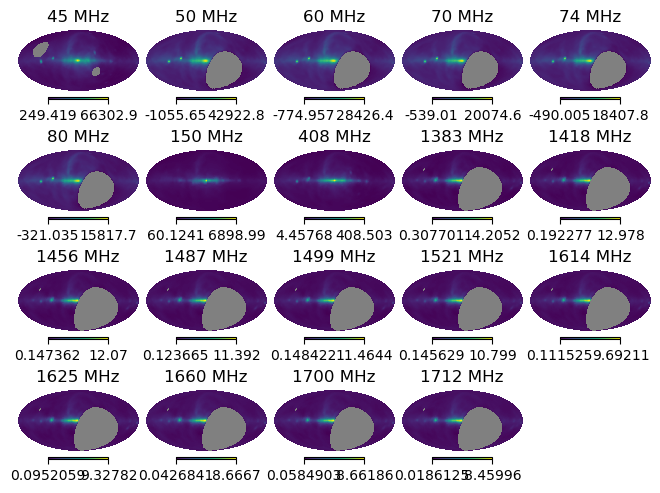

In [21]:
label ="north"
udgrade= True  


######################
hdul = fits.open(f"../inputmaps/coarse_{label}_maps_nside256.fits" ) 
df = pd.DataFrame()
cols = hdul[1].columns.names
cols = cols 
df['frequency'] = np.float_(cols  )/1e3
data = hdul[1].data

nfreq=len(cols)
mapserr_table = np.load(f"../inputmaps/coarse_{label}_errors_dict.npz")
errv = [v  for v in mapserr_table.values() ] 
df['depth_i']= errv 

instrument = df.dropna(axis=1, how='all')
hdul.close()


freq_maps=hp.read_map(f"../inputmaps/coarse_{label}_maps_nside256.fits",  field=cols  )

if udgrade:
    nside_new = 64
    
    noise_factor = np.sqrt(hp.nside2npix(hp.get_nside (freq_maps[0 ])) /hp.nside2npix( nside_new )  )
    instrument['depth_i'] /= noise_factor
    j=0
    freq_maps_ud=[]
    for i  in range(nfreq ):
    
        mask =np.isnan(freq_maps[i] )
        freq_maps[i][mask]=hp.UNSEEN 

        freq_maps_ud.append( hp.ud_grade(freq_maps[i] , nside_out=nside_new   ))
    freq_maps=np.vstack(freq_maps_ud)


freq_maps= freq_maps.reshape( freq_maps.shape[0],1,  freq_maps.shape[1])

print(instrument ) 
for i  in range(nfreq ):
    hp.mollview(   freq_maps[i,0  ]     , 
                 title=f'{cols[i] } MHz'  , 
                sub=(4,5,1+i) , notext=True)

In [9]:


nside = 64 
options={'disp':False , 'gtol': 1e-18, 'eps': 1e-18,   'maxiter': 1000, 'ftol': 1e-18 }
tol = 1e-18
method='TNC'
components =[  Synchrotron(nu0=1.4, running=None   ,  units='K_RJ'  ) , 
                  FreeFree(nu0=2. ,  units='K_RJ'  ) 
                    ]


print(components[0].n_param, components[1].n_param , hp.get_nside(freq_maps[0,:,:]) )
nsidepatches = [nside, nside , nside ,nside    ]


#-------------   no maskfreq 

#maskfreq= np.ma.masked_inside(df['frequency'],0.05 ,0.08).mask  
#instrument[~maskfreq], freq_maps[~maskfreq] 


3 1 64


## run north 

In [22]:
results   = sr.multi_res_comp_sep(components, instrument  , freq_maps  ,
                                  nsides= nsidepatches ,
                                    method=method,
                                    tol = tol,
                                     options=options,
                                    #bounds=bounds,
                                    )
np.savez(f'../outputs/fgbuster_params_{label}_nside{nside}.npz',
                  **{n: a for n, a in zip(results.params, results.x)})

KeyboardInterrupt: 

In [5]:
(results.chi.shape, freq_maps.shape , results.invAtNA.shape )




((14, 1, 49152), (19, 1, 49152), (49152, 1, 2, 2))

In [6]:
results.invAtNA[:,0,0,0].shape

(49152,)

In [ ]:
pl.figure( figsize=(18, 12))

betas =  (results.x_map[0])  
nup =  (results.x_map[1])
print( nup[nup!= hp.UNSEEN ] .mean() ) 
cs =results.x_map[2]  
betaf =results.x_map[3]  
hp.mollview(betas , title='beta_s' , cmap='RdBu_r', min=-3.2,max=-2.8,sub=221   )
hp.mollview(nup , title='nu_p' , cmap='RdBu_r' , sub=222)
hp.mollview(cs , title='c_s' , cmap='RdBu_r' , min=-0.2, max=0.2   , sub=223 )  
hp.mollview(betaf , title='beta_f' , cmap='RdBu_r', min=-2.3, max=-2.0 , sub=224)

hp.graticule () 

In [12]:
results.message

'Linear search failed'

In [ ]:
label ="south"
udgrade= True 


######################
hdul = fits.open(f"../inputmaps/coarse_{label}_maps_nside256.fits" ) 
df = pd.DataFrame()
cols = hdul[1].columns.names
cols = cols 
df['frequency'] = np.float_(cols  )/1e3
data = hdul[1].data

nfreq=len(cols)
mapserr_table = np.load(f"../inputmaps/coarse_{label}_errors_dict.npz")
errv = [v for v in mapserr_table.values() ] 
df['depth_i']= errv 
instrument = df.dropna(axis=1, how='all')
hdul.close()

freq_maps=hp.read_map(f"../inputmaps/coarse_{label}_maps_nside256.fits",  field=cols  )

if udgrade:
    nside_new = 64
    noise_factor = np.sqrt(hp.nside2npix(hp.get_nside (freq_maps[0 ])) /hp.nside2npix( nside_new )  )
    instrument['depth_i'] /= noise_factor
    j=0
    freq_maps_ud=[]
    for i  in range(nfreq ):
    
        mask =np.isnan(freq_maps[i] )
        freq_maps[i][mask]=hp.UNSEEN 

        freq_maps_ud.append( hp.ud_grade(freq_maps[i] , nside_out=nside_new   ))
    freq_maps=np.vstack(freq_maps_ud)


freq_maps= freq_maps.reshape( freq_maps.shape[0],1,  freq_maps.shape[1])


for i  in range(nfreq ):
    hp.mollview(   freq_maps[i,0  ]     , 
                 title=f'{cols[i] } MHz'  , 
                sub=(4,5,1+i) , notext=True)

In [14]:
instrument, hp.get_nside(freq_maps[0,:,:])

(    frequency   depth_i
 0       0.045      75.0
 1       0.150      10.0
 2       0.408     0.025
 3       1.324     0.004
 4       1.349  0.003888
 5       1.374  0.003776
 6       1.456  0.003408
 7       1.524  0.003103
 8       1.609  0.002722
 9       1.628  0.002637
 10      1.700  0.002314
 11      1.749  0.002094
 12      1.770     0.002,
 64)

## run south 

In [ ]:


nside = 64
options={'disp':False , 'gtol': 1e-18, 'eps': 1e-18,   'maxiter': 1000, 'ftol': 1e-18 }
tol = 1e-18
method='TNC'
components =[  Synchrotron(nu0=1.4, running=None   ,  units='K_RJ'   ) , 
                  FreeFree(nu0=2. ,  units='K_RJ'  )
                    ]

print(components[0].n_param, components[1].n_param , hp.get_nside(freq_maps[0,:,:]) )
nsidepatches = [nside, nside , nside ,nside     ]




results   = sr.multi_res_comp_sep(components, instrument, freq_maps,  
                                  nsides= nsidepatches ,
                                    method=method,
                                    tol = tol,
                                     options=options,
                                    #bounds=bounds,
                                    )

np.savez(f'../outputs/fgbuster_params_{label}_nside{nside}.npz',
                  **{n: a for n, a in zip(results.params, results.x)})

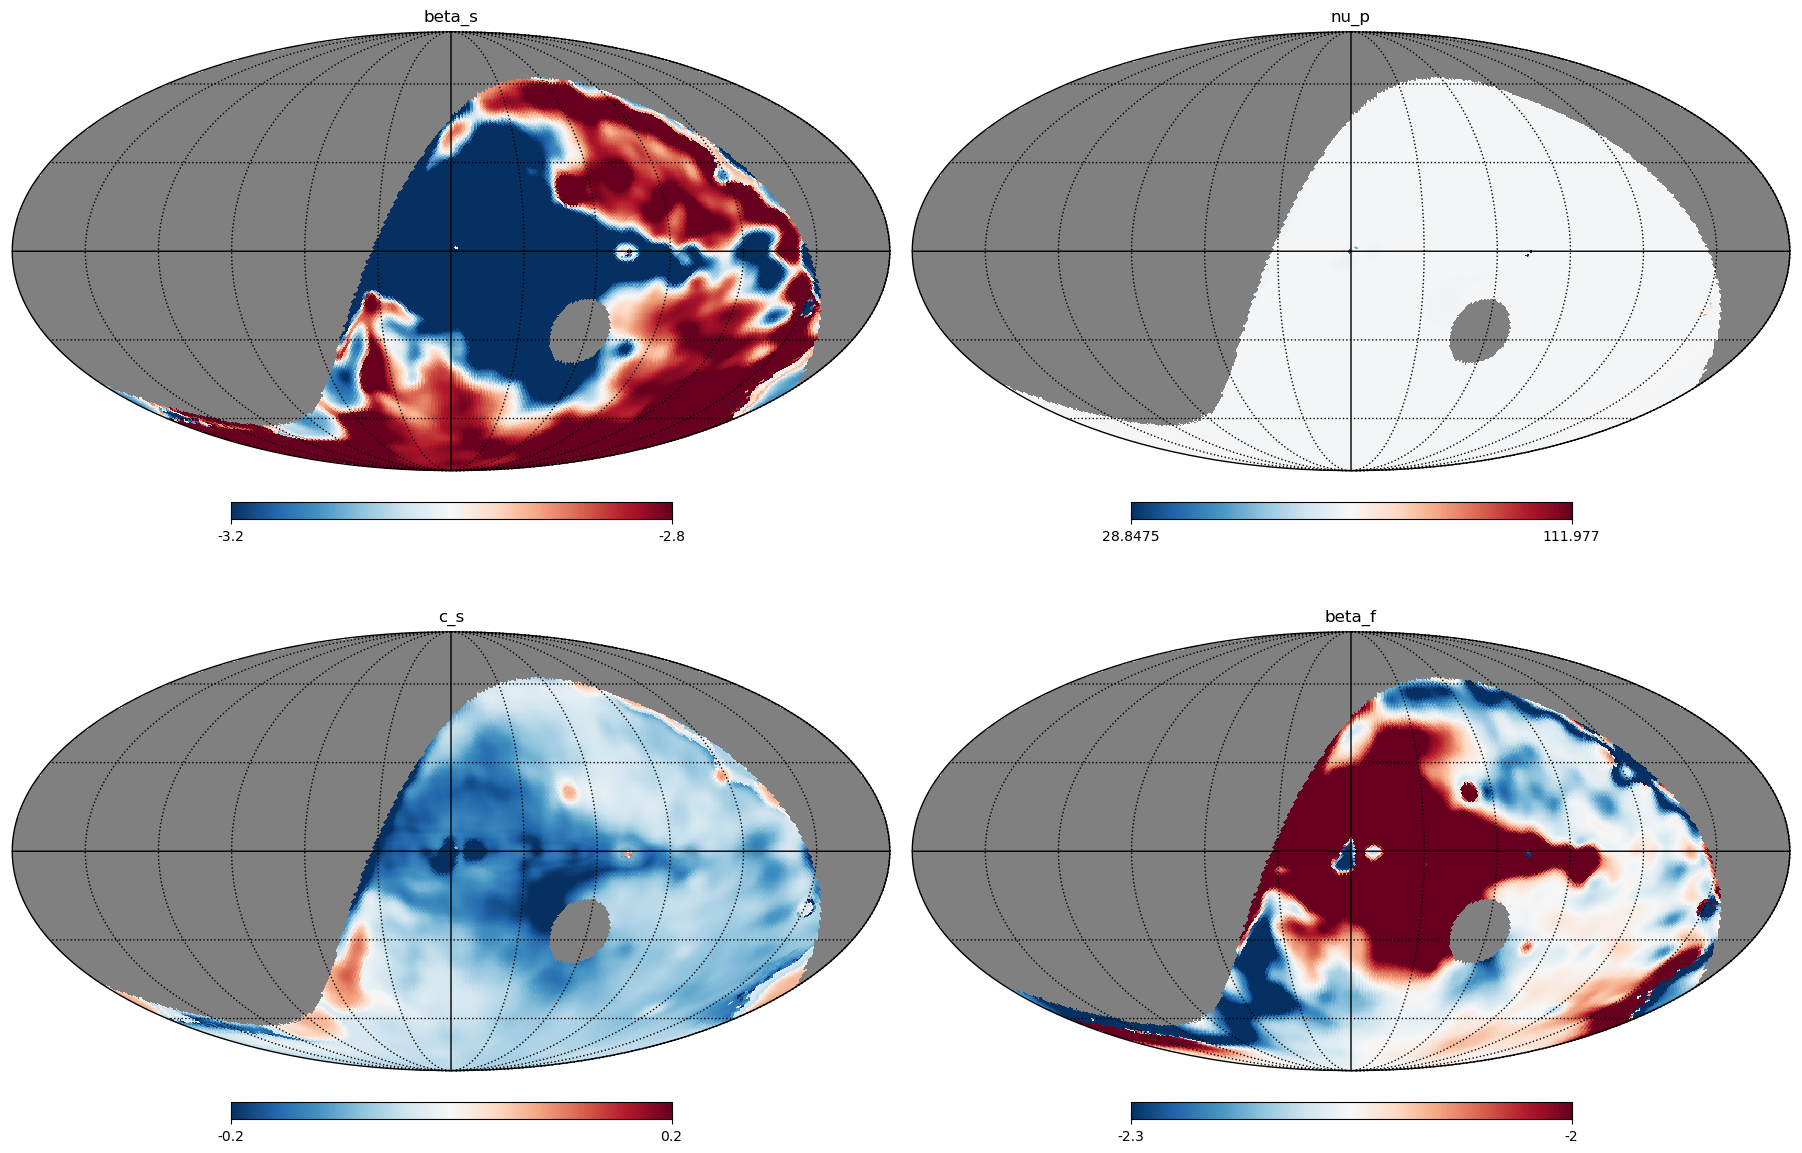

In [16]:
pl.figure( figsize=(18, 12))

betas =  (results.x_map[0])  
nup =  (results.x_map[1])
cs =results.x_map[2]  
betaf =results.x_map[3]  
hp.mollview(betas , title='beta_s' , cmap='RdBu_r', min=-3.2,max=-2.8,sub=221   )
hp.mollview(nup , title='nu_p' , cmap='RdBu_r' , sub=222)
hp.mollview(cs , title='c_s' , cmap='RdBu_r' , min=-0.2, max=0.2   , sub=223 )  
hp.mollview(betaf , title='beta_f' , cmap='RdBu_r', min=-2.3, max=-2.0 , sub=224)

hp.graticule() 

## combine data

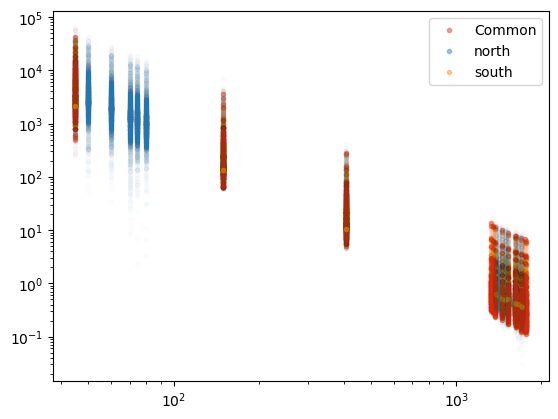

In [17]:
y = freq_maps[:,0,::200]

freqs = np.asarray(instrument['frequency'])

    # 1) scatter all samples (fast)
x = np.repeat(freqs[:, None], y.shape[1], axis=1)*1e3  # same shape as y
pl.semilogy (x, y ,f'C{3}.', alpha=0.4 )
pl.semilogy (x[:,0], y[:,0] ,f'C{3}.' , alpha=.4, label="Common" )
labels = ['north', 'south' ]
udgrade= False 
jj=0
for   label in  (labels):
    ######################
    hdul = fits.open(f"../inputmaps/coarse_{label}_maps_nside256.fits" ) 
    df = pd.DataFrame()
    cols = hdul[1].columns.names
    cols = cols 
    df['frequency'] = np.float_(cols  )/1e3
    data = hdul[1].data

    nfreq=len(cols)
    mapserr_table = np.load(f"../inputmaps/coarse_{label}_errors_dict.npz")
    errv = [v for v in mapserr_table.values() ] 
    df['depth_i']= errv 
    instrument = df.dropna(axis=1, how='all')
    hdul.close()

    freq_maps=hp.read_map(f"../inputmaps/coarse_{label}_maps_nside256.fits",  field=cols  )


    if udgrade:
        nside_new = 64
        noise_factor = np.sqrt(hp.nside2npix(hp.get_nside (freq_maps[0 ])) /hp.nside2npix( nside_new )  )
        instrument['depth_i'] /= noise_factor
        j=0
        freq_maps_ud=[]
        for i  in range(nfreq ):
        
            mask =np.isnan(freq_maps[i] )
            freq_maps[i][mask]=hp.UNSEEN 

            freq_maps_ud.append( hp.ud_grade(freq_maps[i] , nside_out=nside_new   ))
        freq_maps=np.vstack(freq_maps_ud)


    freq_maps= freq_maps.reshape( freq_maps.shape[0],1,  freq_maps.shape[1])
    y = freq_maps[:,0,::200]

    freqs = np.asarray(instrument['frequency'])

    # 1) scatter all samples (fast)
    x = np.repeat(freqs[:, None], y.shape[1], axis=1)*1e3  # same shape as y
    pl.semilogy (x, y ,f'C{jj}.', alpha=0.01 )
    pl.semilogy (x[:,0], y[:,0] ,f'C{jj}.' , alpha=.4, label=label )
    pl.legend() 
    pl.loglog() 

    jj+=1

50 0.03840163729247811
100 0.011673876946521427
150 0.004482742071949128
187
50 0.021033980258746254
80
50 0.007646129126633731
100 0.0023225131082893883
116
50 0.010839848976741262
100 0.0028278492304233474
124


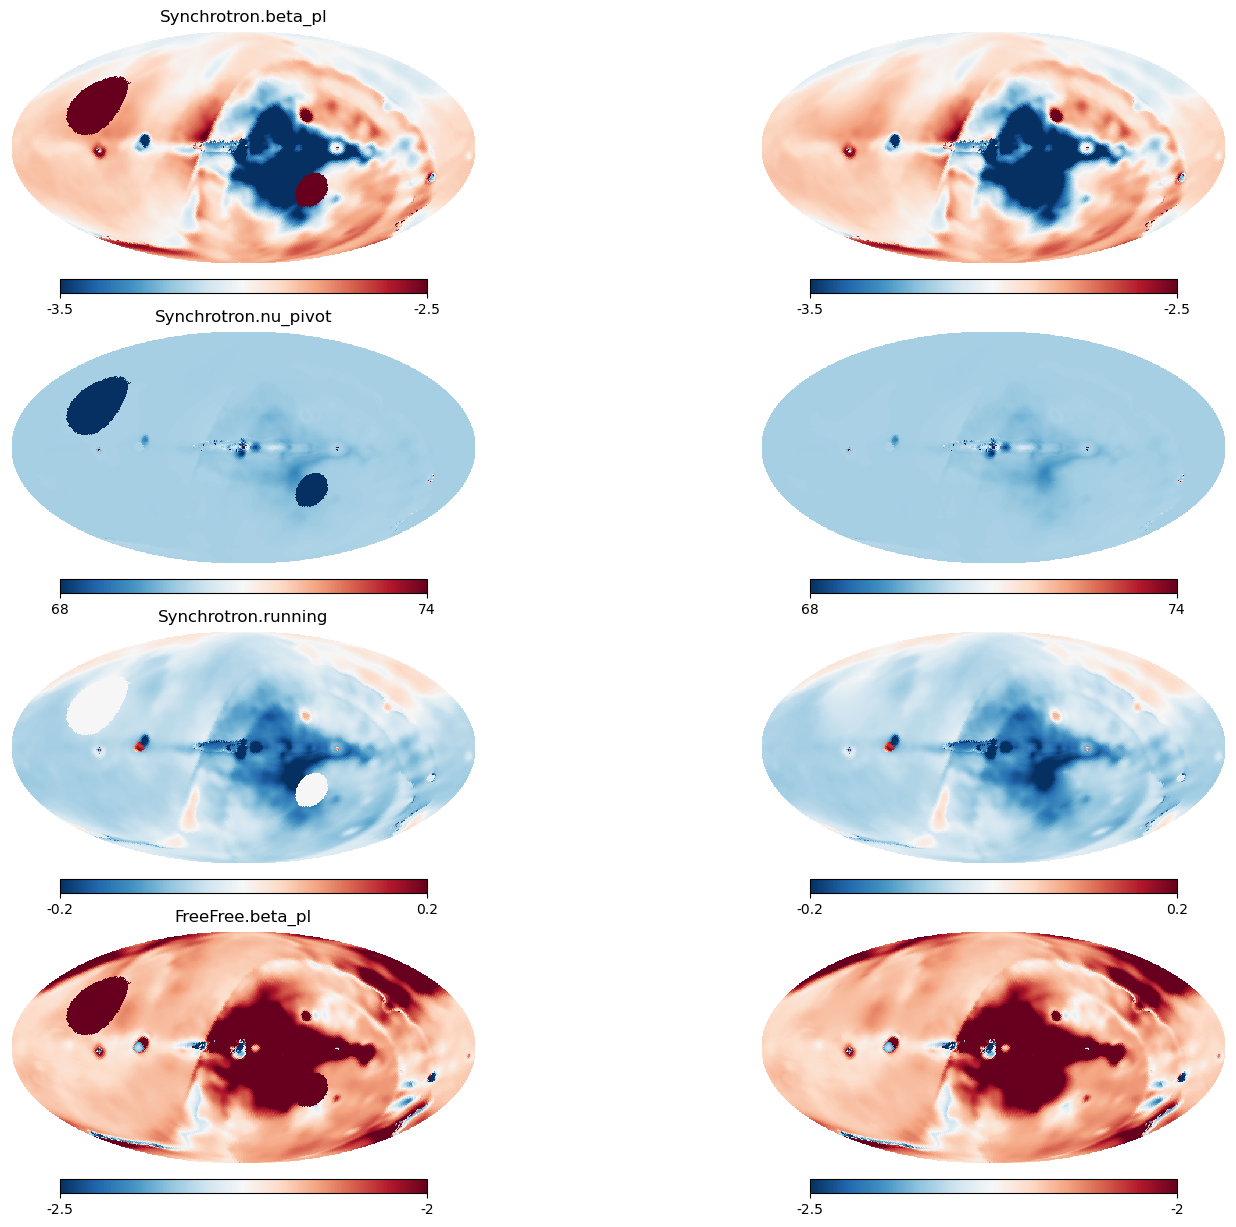

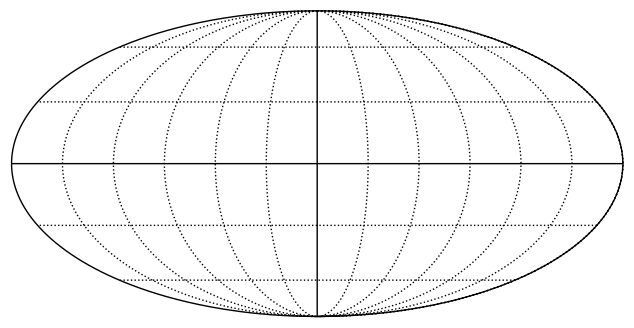

In [18]:
nside=64
common_apo =hp.read_map('../common_south_north_apo.fits' )
valid_north = hp.read_map(f"../valid_north_apo.fits" )
valid_south = hp.read_map(f"../valid_south_apo.fits" )
combined_dic ={} 

kk=0
pl.figure(figsize=(15,12)    )
for comp, comps  in zip(["Synchrotron", "FreeFree"], components):
    for p in comps.params: 
        
        if comp =="Synchrotron" and p=="running":
            min=-0.2
            max=0.2
        elif comp =="Synchrotron" and p=="beta_pl":
            min=-3.5
            max=-2.5

        elif comp =="FreeFree" and p=="beta_pl":
            min=-2.5
            max=-2.
        else: 
            min=68
            max=74 
        resnorth = np.load(f'../outputs/fgbuster_params_north_nside{nside}.npz' )[f"{comp}.{p}"]
        ressouth = np.load(f'../outputs/fgbuster_params_south_nside{nside}.npz' )[f"{comp}.{p}"]
        nan_north = resnorth == hp.UNSEEN
        nan_south = ressouth == hp.UNSEEN

        ressouth [nan_south]= 0. 
        resnorth [nan_north]= 0. 

        apo_pixs =np.logical_and( np.logical_or(np.ma.masked_inside(valid_north ,1e-14,.99999 ).mask   , np.ma.masked_inside(valid_south ,1e-14,.99999 ).mask  ), np.ma.masked_outside(common_apo ,1e-14 ,.99999 ).mask)  
        weigths =np.ones (ressouth.shape )+  (common_apo)  
        combined =   (ressouth *valid_south   + resnorth *valid_north  ) / ( weigths    )  
        combined[apo_pixs ]= ( ressouth[apo_pixs ] + resnorth[apo_pixs ] )   

        hp.mollview(combined  ,sub=421+kk , min=min, max=max, cmap='RdBu_r' , title=comp+"." +p )

        holes = np.where(combined == 0.  ) [0] 

        combined[holes]= np.nan 
        nside= hp.get_nside(combined)
        theta,phi = hp.pix2ang(ipix=holes, nside=nside, lonlat=False)
        neighbs = hp.get_all_neighbours(nside,theta,phi, lonlat=False)
        
          

        c=0
        while True:
            tmp = combined[holes].copy() 
            for jj, ipix in enumerate(holes) : 
                fill_neighb = ~pl.ma.masked_invalid(combined[neighbs[:, jj]] ).mask 
                
                combined[ipix] = pl.mean(combined[neighbs[fill_neighb, jj] ])
            if pl.allclose(combined[holes], tmp,atol=1e-4  ): break 
            c+=1

            if c%50==0: 
                print(c, pl.linalg.norm(combined[holes] - tmp ))  
                #pl.figure() 
                #hp.mollview(m-morig,sub=122) 
            #if c>500: break 

        print(c )
        hp.mollview(combined  ,sub=422+kk , min=min, max=max, cmap='RdBu_r', title= ''  )
        combined_dic[f"{comp}.{p}"]= combined 
        kk+=2

    
pl.show() 
hp.graticule() 

In [19]:
np.savez(f'../outputs/fgbuster_filled_maps_nside{nside}_coarse.npz',
                  **{n: a for n, a in zip(combined_dic.keys(), combined_dic.values())}) 